In [41]:
import sys
import nibabel as nib
import numpy as np
sys.path.append("/cs/casmip/alina.ryabtsev/Tools")
from CalculateMeasures import calculate_measures_dataframe, calculate_measures
from glob import glob
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%reload_ext autoreload
%autoreload 2

In [26]:

# Load the data
DATA_PATH = "/cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/"
logits_files = glob(DATA_PATH + "*logits*10.nii.gz")
gt_files = [p.replace("logitssupport_analysis_10.nii.gz", "seg.nii.gz") for p in logits_files]
liver_files = [p.replace("logitssupport_analysis_10.nii.gz", "liver.nii.gz") for p in logits_files]

In [4]:
# load niftis
niftis = [nib.load(f) for f in logits_files]
logits = [n.get_fdata() for n in niftis]

In [5]:
sigmoids = [np.around(torch.sigmoid(torch.from_numpy(l)).numpy(), decimals=1)*10 for l in logits]

In [ ]:
threshold_range = range(1,11)
thresholds_data = calculate_measures_dataframe("tumors", sigmoids, gt_files, threshold_range, roi_list=liver_files)

In [27]:
threshold_range = range(1,11)
calculate_measures("tumors", sigmoids, gt_files, threshold_range, excel_path="./recall_threshold_analysis.xlsx", roi_list=liver_files)

Calculating measures for threshold 1


100%|██████████| 83/83 [16:04<00:00, 11.63s/it]


Writing measures for threshold 1 finished
Calculating measures for threshold 2


100%|██████████| 83/83 [14:59<00:00, 10.84s/it]


Writing measures for threshold 2 finished
Calculating measures for threshold 3


...

Writing measures for threshold 8 finished
Calculating measures for threshold 9


100%|██████████| 83/83 [07:07<00:00,  5.15s/it]


Writing measures for threshold 9 finished
Calculating measures for threshold 10


100%|██████████| 83/83 [06:38<00:00,  4.81s/it]


Writing measures for threshold 10 finished


Now we would like to perform recall-precision curve for all thresholds.

In [120]:
excel_thresholds_files_path = "/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis"
recalls = {i : 0 for i in range(1,11)}
precisions = {i: 0 for i in range(1,11)}
f1s = {i: 0 for i in range(1,11)}
dices = {i: 0 for i in range(1, 11)}
assds = {i: 0 for i in range(1, 11)}
hausdorffs = {i: 0 for i in range(1, 11)}
excel_thresholds_files = sorted(glob(os.path.join(excel_thresholds_files_path, "Threshold_*.xlsx")), key=lambda x: os.path.getmtime(x))

In [58]:
excel_thresholds_files

['/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_1.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_2.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_3.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_4.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_5.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_6.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_7.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_8.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recall_threshold_analysis/Threshold_9.xlsx',
 '/cs/casmip/alina.ryabtsev/FewShotLearning/test_universeg/recal

In [121]:
for i, excel in enumerate(excel_thresholds_files):
    # open file, open sheet name >5 and get the precision and recall tabs
    df = pd.read_excel(excel, sheet_name=">5", header=None, skiprows=84, usecols="Y,Z,AA,C,E,F")
    precisions[i+1] = df.iloc[0][24]
    recalls[i+1] = df.iloc[0][25]
    f1s[i+1] = df.iloc[0][26]
    dices[i+1] = df.iloc[0][2]
    assds[i+1] = df.iloc[0][4]
    hausdorffs[i+1] = df.iloc[0][5]

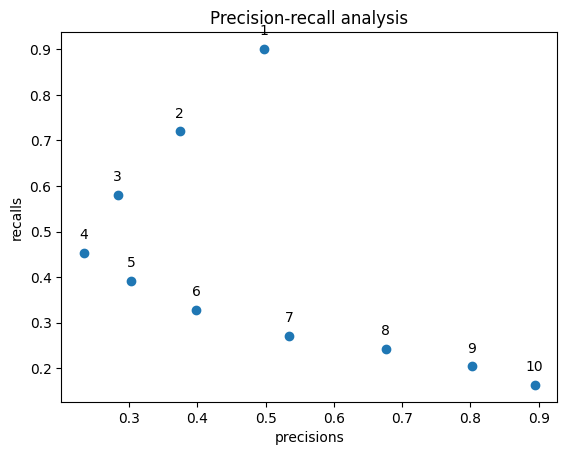

In [102]:
plt.scatter(precisions.values(), recalls.values())
labels = precisions.keys()
for i, label in enumerate(labels):
    plt.annotate(label, (precisions[i+1], recalls[i+1]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlabel("precisions")
plt.ylabel("recalls")
plt.title("Precision-recall analysis")
# Add labels for each point
plt.show()

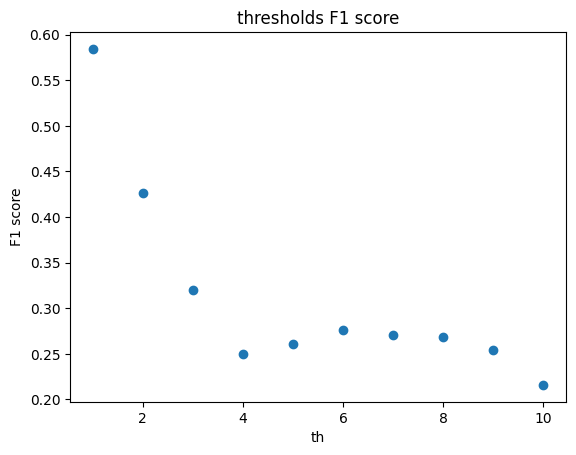

In [101]:
plt.scatter(f1s.keys(), f1s.values())
plt.xlabel("th")
plt.ylabel("F1 score")
plt.title("thresholds F1 score")
plt.show()

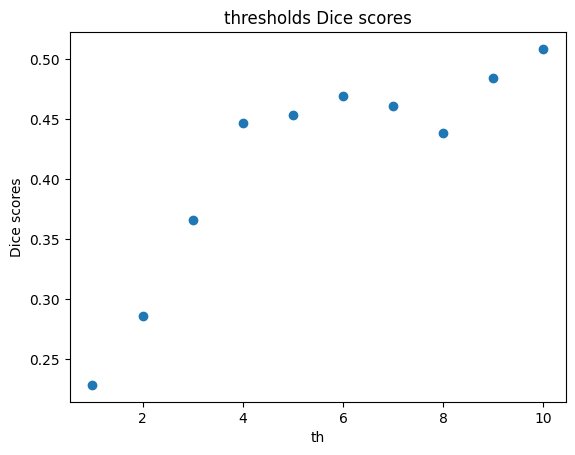

In [81]:
plt.scatter(dices.keys(), dices.values())
plt.xlabel("th")
plt.ylabel("Dice scores")
plt.title("thresholds Dice scores")
plt.show()

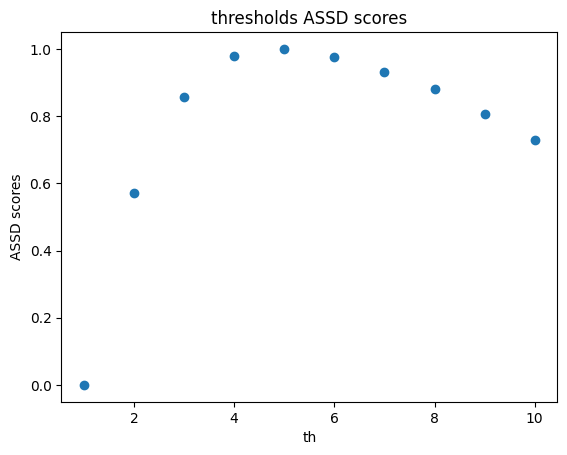

In [88]:
negative_assds = np.array([i*-1 for i in assds.values()])
normalized_assds = (negative_assds - negative_assds.min()) / (negative_assds.max() - negative_assds.min())
plt.scatter(assds.keys(), normalized_assds)
plt.xlabel("th")
plt.ylabel("ASSD scores")
plt.title("thresholds ASSD scores")
plt.show()

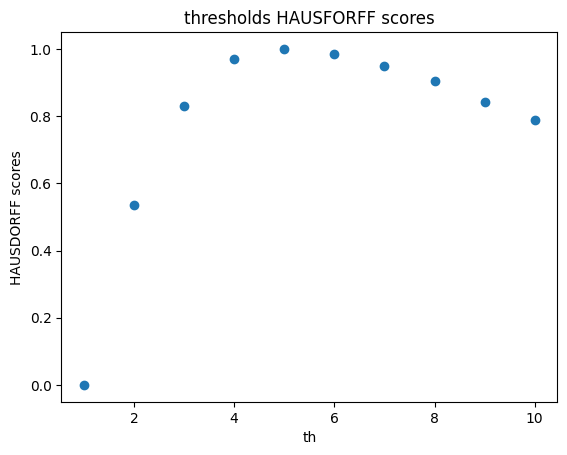

In [122]:
negative_hdss = np.array([i*-1 for i in hausdorffs.values()])
normalized_hds = (negative_hdss - negative_hdss.min()) / (negative_hdss.max() - negative_hdss.min())
plt.scatter(assds.keys(), normalized_hds)
plt.xlabel("th")
plt.ylabel("HAUSDORFF scores")
plt.title("thresholds HAUSFORFF scores")
plt.show()

In [123]:
mutual_distribution = np.array((list(precisions.values()), list(recalls.values()), list(f1s.values()), list(dices.values()), normalized_assds, normalized_hds))
mutual_distribution

array([[0.49678313, 0.37415663, 0.28293976, 0.23351807, 0.3026506 ,
        0.39831325, 0.53389157, 0.6756506 , 0.80155422, 0.89419277],
       [0.90074699, 0.72014458, 0.57977108, 0.45357831, 0.3913494 ,
        0.32854217, 0.271     , 0.24220482, 0.20436145, 0.16331325],
       [0.5843494 , 0.42659036, 0.31963855, 0.24959036, 0.26110843,
        0.27628916, 0.27114458, 0.26873494, 0.25377108, 0.21586747],
       [0.22861446, 0.28621687, 0.3656988 , 0.44701205, 0.45328916,
        0.46942169, 0.4606747 , 0.43827711, 0.48415663, 0.50828916],
       [0.        , 0.56993098, 0.85765571, 0.97836899, 1.        ,
        0.97601328, 0.93273446, 0.87957764, 0.80606669, 0.72807582],
       [0.        , 0.53678501, 0.82930572, 0.96918002, 1.        ,
        0.98388241, 0.94783203, 0.90472272, 0.84302837, 0.78934791]])

In [125]:
np.argmax(np.mean(mutual_distribution, axis=0)) + 1

6

It seems that choosing threshold 6 might provide better results, at least in terms of segmentation where it obtained higher dice than threshold 5. Also, it obtained higher precision and F1 score than th=5.